In [1]:
# ============================================================
# CELL 2: IMPORTS
# All libraries imported once here — never import again below
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from skimage import filters, morphology
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✓ All libraries imported successfully")


✓ All libraries imported successfully


In [2]:
# ============================================================
# CELL 3: ONLY CERTAIN KNOWLEDGE
# dataset path + disease domain knowledge (severity order)
# Nothing else — we discover everything from data
# ============================================================
dataset_path = Path(r"E:\ALZ")

severity_mapping = {
    'NonDemented'      : 0,
    'VeryMildDemented' : 1,
    'MildDemented'     : 2,
    'ModerateDemented' : 3
}
severity_labels = {v: k for k, v in severity_mapping.items()}
SEVERITY_ORDER  = sorted(severity_mapping.keys(), key=severity_mapping.get)

assert dataset_path.exists(), f"❌ Not found: {dataset_path}"

print(f"✓ Path OK        : {dataset_path}")
print(f"✓ Severity order : {SEVERITY_ORDER}")



✓ Path OK        : E:\ALZ
✓ Severity order : ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']


In [3]:
# ============================================================
# CELL 4: DISCOVER NUM_CLASSES + CLASS DISTRIBUTION
# ============================================================
class_distribution = {}

for class_dir in sorted(dataset_path.iterdir()):
    if class_dir.is_dir():
        images = (list(class_dir.glob('*.jpg'))  +
                  list(class_dir.glob('*.jpeg')) +
                  list(class_dir.glob('*.png')))
        class_distribution[class_dir.name] = len(images)

# Discover NUM_CLASSES from actual folder count
NUM_CLASSES = len(class_distribution)
total       = sum(class_distribution.values())

print(f"✓ NUM_CLASSES discovered : {NUM_CLASSES}")
print()
print(f"{'Class':<25} {'Count':>8} {'%':>8}")
print("-" * 43)
for cls in SEVERITY_ORDER:
    count = class_distribution[cls]
    print(f"{cls:<25} {count:>8,} {count/total*100:>7.1f}%")
print(f"\n{'TOTAL':<25} {total:>8,}")


✓ NUM_CLASSES discovered : 5

Class                        Count        %
-------------------------------------------
NonDemented                 12,800    29.1%
VeryMildDemented            11,200    25.5%
MildDemented                10,000    22.7%
ModerateDemented            10,000    22.7%

TOTAL                       44,000


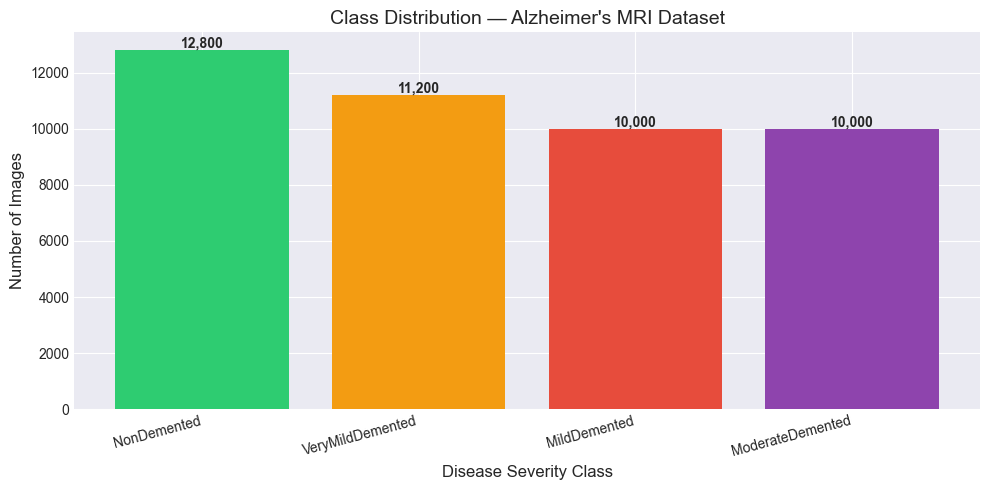

In [4]:
# ============================================================
# CELL 5: CLASS DISTRIBUTION PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

counts = [class_distribution[c] for c in SEVERITY_ORDER]
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
bars   = ax.bar(SEVERITY_ORDER, counts, color=colors)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{int(bar.get_height()):,}',
        ha='center', fontweight='bold', fontsize=10
    )

ax.set_xlabel('Disease Severity Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title("Class Distribution — Alzheimer's MRI Dataset", fontsize=14)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


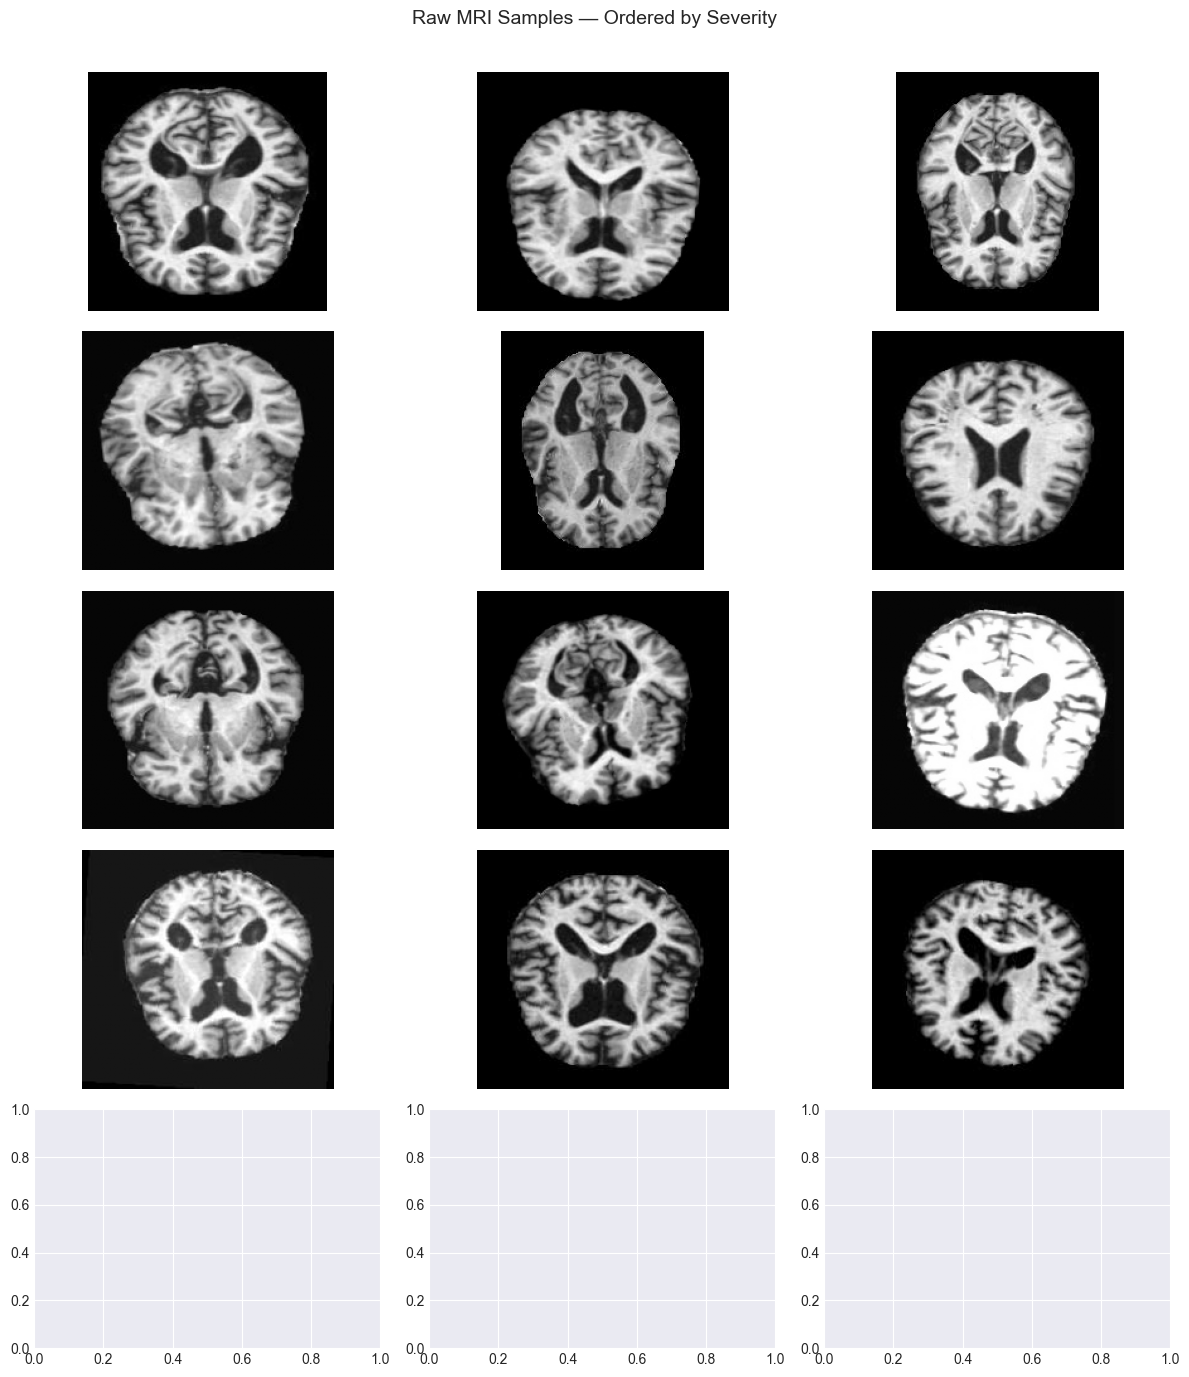

In [5]:
# ============================================================
# CELL 6: SAMPLE RAW IMAGES PER CLASS
# Look at raw data before touching anything
# ============================================================
N_SAMPLES = 3
fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES, figsize=(12, 14))

for row, cls in enumerate(SEVERITY_ORDER):
    images  = list((dataset_path / cls).glob('*.jpg'))
    samples = random.sample(images, N_SAMPLES)

    for col, img_path in enumerate(samples):
        arr = np.array(Image.open(img_path).convert('L'))
        axes[row, col].imshow(arr, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(
                f"[{severity_mapping[cls]}] {cls}",
                fontsize=9, fontweight='bold',
                rotation=0, labelpad=120, va='center'
            )

plt.suptitle('Raw MRI Samples — Ordered by Severity', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [6]:
# ============================================================
# CELL 7: DISCOVER IMAGE SIZES — scan all images
# Reads only file headers, not pixel data → fast
# ============================================================
all_sizes     = []
total_scanned = 0

for class_dir in sorted(dataset_path.iterdir()):
    if not class_dir.is_dir():
        continue
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.jpeg'))
    for img_path in images:
        with Image.open(img_path) as img:
            all_sizes.append(img.size)   # (width, height)
    total_scanned += len(images)

size_counter = Counter(all_sizes)

print(f"Total images scanned : {total_scanned:,}")
print()
print(f"{'Width':>8} {'Height':>8} {'Count':>9} {'%':>8}  Note")
print("-" * 55)
for (w, h), count in sorted(size_counter.items(), key=lambda x: -x[1]):
    pct  = count / total_scanned * 100
    note = "← dominant" if pct > 50 else "← minority"
    print(f"{w:>8} {h:>8} {count:>9,} {pct:>7.1f}%  {note}")


Total images scanned : 44,000

   Width   Height     Count        %  Note
-------------------------------------------------------
     200      190    31,107    70.7%  ← dominant
     180      180     6,447    14.7%  ← minority
     176      208     6,446    14.6%  ← minority


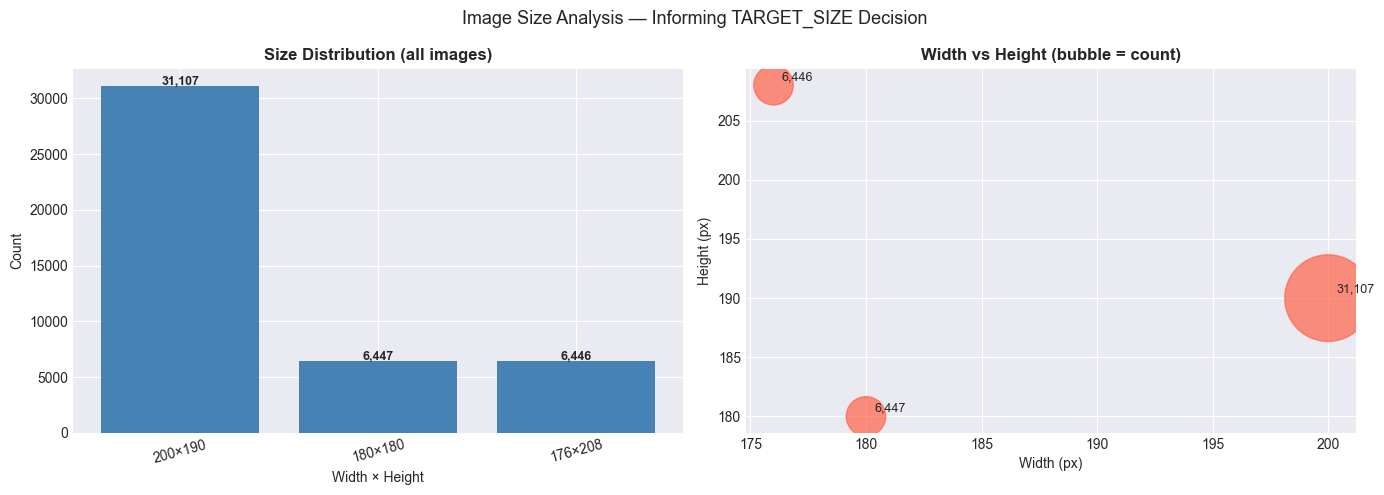

In [7]:
# ============================================================
# CELL 8: SIZE DISTRIBUTION PLOTS
# Visualise what Cell 7 found before deciding TARGET_SIZE
# ============================================================
sizes_df = pd.DataFrame(
    [(w, h, c) for (w, h), c in size_counter.items()],
    columns=['width', 'height', 'count']
).sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart
size_labels = [f"{int(r.width)}×{int(r.height)}" for _, r in sizes_df.iterrows()]
axes[0].bar(size_labels, sizes_df['count'], color='steelblue')
for i, (_, row) in enumerate(sizes_df.iterrows()):
    axes[0].text(i, row['count'] + 100, f"{int(row['count']):,}",
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Size Distribution (all images)', fontweight='bold')
axes[0].set_xlabel('Width × Height')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Right: scatter — width vs height, bubble = count
axes[1].scatter(sizes_df['width'], sizes_df['height'],
                s=sizes_df['count'] / 8, alpha=0.7, color='tomato')
for _, row in sizes_df.iterrows():
    axes[1].annotate(f"{int(row['count']):,}",
                     (row['width'], row['height']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[1].set_title('Width vs Height (bubble = count)', fontweight='bold')
axes[1].set_xlabel('Width (px)')
axes[1].set_ylabel('Height (px)')

plt.suptitle('Image Size Analysis — Informing TARGET_SIZE Decision', fontsize=13)
plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# CELL 9: DECIDE TARGET_SIZE + LOCK ALL REMAINING CONSTANTS
#
# We now know from Cell 7:
#   dominant size, minority sizes, spread
#
# Decision rules for TARGET_SIZE:
#   Rule 1 — Square: U-Net, CycleGAN, ResNet all expect equal
#             width and height (symmetric pooling layers)
#   Rule 2 — Divisible by 32: deep networks apply 5 maxpool
#             layers (2^5=32), input must divide evenly
#   Rule 3 — Close to dominant size: minimises information loss
#
# We compute this from the data — no hardcoding
# ============================================================

# Step 1: Extract dominant size from discovery
dominant_size, dominant_count = size_counter.most_common(1)[0]
dom_w, dom_h = dominant_size
dom_pct      = dominant_count / total_scanned * 100

print("What we discovered in Cell 7:")
print(f"  Dominant size : {dom_w} × {dom_h}  ({dom_pct:.1f}% of images)")
print(f"  Minority sizes: {[s for s, _ in size_counter.most_common()[1:]]}")
print()

# Step 2: Compute nearest square multiple of 32
max_side      = max(dom_w, dom_h)
nearest_div32 = int(np.ceil(max_side / 32) * 32)

print(f"Largest dimension of dominant size : {max_side} px")
print(f"Nearest multiple of 32 ≥ {max_side}    : {nearest_div32} px")
print()

# Step 3: Show all candidates
print(f"{'Candidate':>10} {'÷32?':>6} {'Δ from dominant':>18}  Decision")
print("-" * 58)
candidates = [128, 160, 192, 224, 256]
for c in candidates:
    div32   = "✓" if c % 32 == 0 else "✗"
    delta   = abs(c - max_side)
    verdict = "← AUTO-SELECTED (nearest div-32 to dominant)" \
              if c == nearest_div32 else ""
    print(f"  {c:>4}×{c:<6} {div32:>5}   {delta:>5} px   {verdict}")

print()

# Step 4: Lock TARGET_SIZE from computation
TARGET_SIZE = (nearest_div32, nearest_div32)

# Step 5: Lock remaining constants now that we understand the data
# SAMPLE_SIZE = 200 per class — large enough for stable EDA statistics,
#               small enough to run fast given our 44K image dataset
# RANDOM_SEED = 42 — fixed for full reproducibility of all sampling,
#               splits and model weight initialisation
SAMPLE_SIZE = 200
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("=" * 55)
print("✓ ALL CONSTANTS NOW LOCKED")
print("=" * 55)
print(f"  NUM_CLASSES  : {NUM_CLASSES}   (discovered Cell 4)")
print(f"  TARGET_SIZE  : {TARGET_SIZE}  (computed  Cell 9)")
print(f"  SAMPLE_SIZE  : {SAMPLE_SIZE}       (decided   Cell 9)")
print(f"  RANDOM_SEED  : {RANDOM_SEED}        (decided   Cell 9)")
print("=" * 55)
print()
print("→ Next: Cell 10 — Define preprocessing functions")


What we discovered in Cell 7:
  Dominant size : 200 × 190  (70.7% of images)
  Minority sizes: [(180, 180), (176, 208)]

Largest dimension of dominant size : 200 px
Nearest multiple of 32 ≥ 200    : 224 px

 Candidate   ÷32?    Δ from dominant  Decision
----------------------------------------------------------
   128×128        ✓      72 px   
   160×160        ✓      40 px   
   192×192        ✓       8 px   
   224×224        ✓      24 px   ← AUTO-SELECTED (nearest div-32 to dominant)
   256×256        ✓      56 px   

✓ ALL CONSTANTS NOW LOCKED
  NUM_CLASSES  : 5   (discovered Cell 4)
  TARGET_SIZE  : (224, 224)  (computed  Cell 9)
  SAMPLE_SIZE  : 200       (decided   Cell 9)
  RANDOM_SEED  : 42        (decided   Cell 9)

→ Next: Cell 10 — Define preprocessing functions


In [9]:
# ============================================================
# CELL 10: ALL PREPROCESSING FUNCTIONS (FINAL FIX)
# ============================================================

def crop_to_brain(img_array, margin=10):
    """
    Crop to brain bounding box, removing pre-existing black borders.
    Uses threshold > 10 to handle JPEG compression artifacts
    that appear as near-zero non-black pixels near edges.
    """
    rows = np.any(img_array > 10, axis=1)
    cols = np.any(img_array > 10, axis=0)

    if not rows.any() or not cols.any():
        return img_array

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    rmin = max(0, rmin - margin)
    rmax = min(img_array.shape[0], rmax + margin)
    cmin = max(0, cmin - margin)
    cmax = min(img_array.shape[1], cmax + margin)

    return img_array[rmin:rmax, cmin:cmax]


In [10]:

def pad_to_square(img_array):
    """
    Pad shorter dimension with zeros to make image square.
    No stretching — proportions fully preserved.
    """
    h, w    = img_array.shape[:2]
    max_dim = max(h, w)
    canvas  = np.zeros((max_dim, max_dim), dtype=img_array.dtype)
    top     = (max_dim - h) // 2
    left    = (max_dim - w) // 2
    canvas[top:top + h, left:left + w] = img_array
    return canvas



In [11]:
def normalize_minmax(arr):
    """
    Min-max normalize brain pixels to [0, 1].
    Background (≤10) stays at 0.

    Why min-max instead of z-score?
    - Z-score produces negative values for dark tissue
    - Setting background to 0 then clips valid dark brain pixels
    - Min-max avoids this: all brain pixels land in [0,1]
    - Background at 0 is naturally separate from brain at (0,1]
    - Models work equally well with [0,1] normalized inputs

    Note: We will apply per-batch z-score standardisation
    inside the DataLoader later during model training.
    This normalization is for storage and EDA.
    """
    arr        = arr.astype(np.float32)
    background = (arr <= 10)
    brain_px   = arr[~background]

    if len(brain_px) == 0:
        return arr

    mn  = brain_px.min()
    mx  = brain_px.max()

    if mx - mn == 0:
        return arr

    # Scale brain pixels to [0, 1]
    normed             = (arr - mn) / (mx - mn)
    normed[background] = 0.0   # background explicitly stays 0

    return normed


In [12]:




def preprocess_image(img_path, target_size=None):
    """
    Master preprocessing function for ALL project phases.

    Pipeline:
        1. Load as grayscale
        2. Crop pre-existing black borders (crop_to_brain)
        3. Pad to square              (pad_to_square)
        4. Resize to TARGET_SIZE      (bicubic)
        5. Min-max normalize          (normalize_minmax)

    Returns: float32 array in range [0, 1], shape = TARGET_SIZE
    """
    if target_size is None:
        target_size = TARGET_SIZE

    arr = np.array(Image.open(img_path).convert('L'))
    arr = crop_to_brain(arr, margin=10)
    arr = pad_to_square(arr)
    arr = np.array(
        Image.fromarray(arr).resize(target_size, Image.BICUBIC),
        dtype=np.float32
    )
    arr = normalize_minmax(arr)
    return arr




In [13]:
print("✓ Preprocessing functions (final version):")
print("    crop_to_brain(img_array, margin=10)")
print("    pad_to_square(img_array)")
print("    normalize_minmax(arr)  ← replaces z-score for storage/EDA")
print("    preprocess_image(img_path)")
print()
print("  Brain pixel range after preprocessing: [0, 1]")
print("  Background value after preprocessing : 0.0")


✓ Preprocessing functions (final version):
    crop_to_brain(img_array, margin=10)
    pad_to_square(img_array)
    normalize_minmax(arr)  ← replaces z-score for storage/EDA
    preprocess_image(img_path)

  Brain pixel range after preprocessing: [0, 1]
  Background value after preprocessing : 0.0


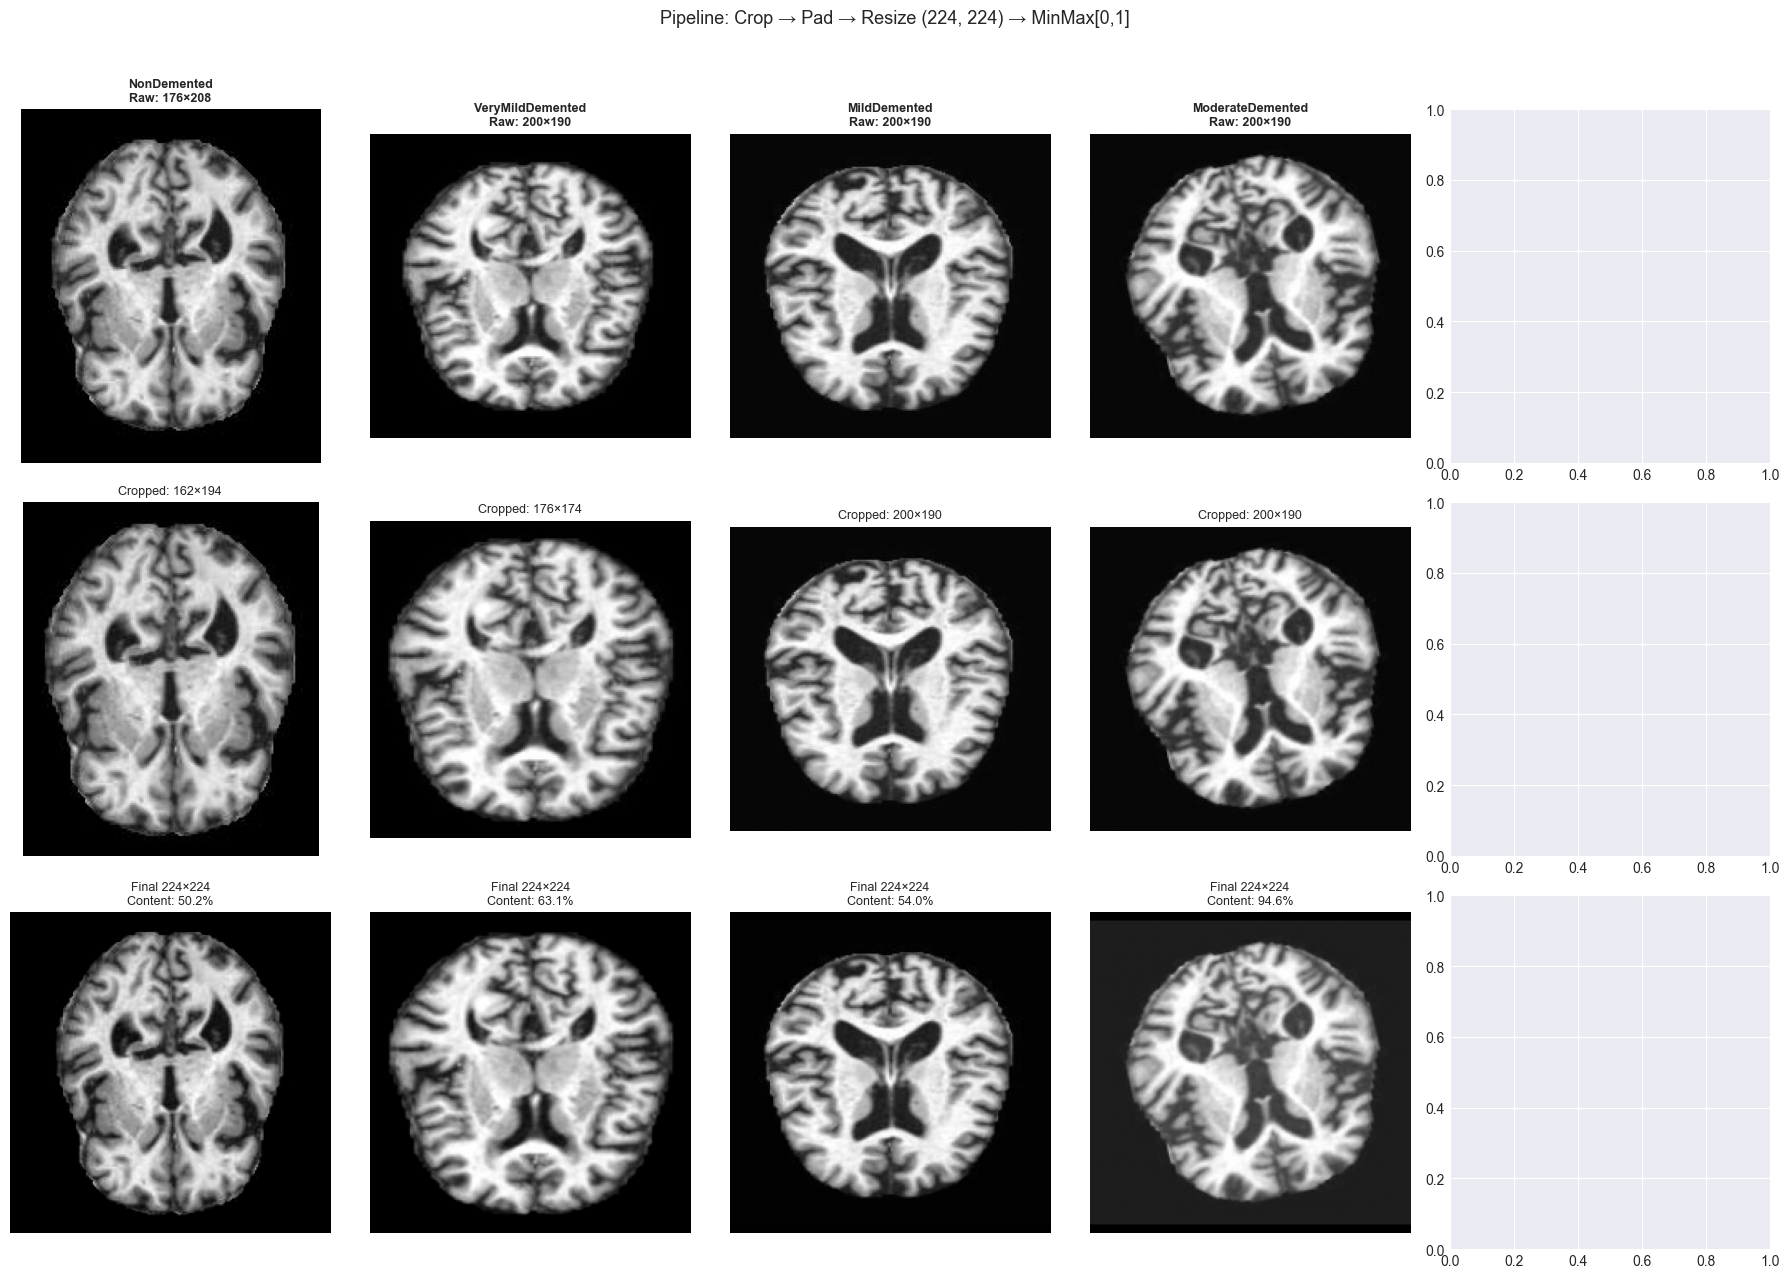

In [14]:
# ============================================================
# CELL 11: VISUAL VERIFICATION (FINAL)
# ============================================================
fig, axes = plt.subplots(3, NUM_CLASSES, figsize=(18, 13))

for idx, cls in enumerate(SEVERITY_ORDER):
    images   = list((dataset_path / cls).glob('*.jpg'))
    img_path = random.choice(images)

    raw     = np.array(Image.open(img_path).convert('L'))
    cropped = crop_to_brain(raw, margin=10)
    final   = preprocess_image(img_path)

    # Brain content: pixels meaningfully above 0
    content = (final > 0.01).sum() / (TARGET_SIZE[0] * TARGET_SIZE[1]) * 100

    # Row 1: Raw
    axes[0, idx].imshow(raw,     cmap='gray')
    axes[0, idx].set_title(
        f'{cls}\nRaw: {raw.shape[1]}×{raw.shape[0]}',
        fontsize=9, fontweight='bold')
    axes[0, idx].axis('off')

    # Row 2: Cropped
    axes[1, idx].imshow(cropped, cmap='gray')
    axes[1, idx].set_title(
        f'Cropped: {cropped.shape[1]}×{cropped.shape[0]}',
        fontsize=9)
    axes[1, idx].axis('off')

    # Row 3: Final — [0,1] range displays correctly, no vmin/vmax needed
    axes[2, idx].imshow(final,   cmap='gray')
    axes[2, idx].set_title(
        f'Final {TARGET_SIZE[0]}×{TARGET_SIZE[1]}\nContent: {content:.1f}%',
        fontsize=9)
    axes[2, idx].axis('off')

axes[0, 0].set_ylabel('Step 1\nRaw',    fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Step 2\nCrop',   fontsize=10, fontweight='bold')
axes[2, 0].set_ylabel('Step 3\nFinal',  fontsize=10, fontweight='bold')

plt.suptitle(
    f'Pipeline: Crop → Pad → Resize {TARGET_SIZE} → MinMax[0,1]',
    fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [15]:
# ============================================================
# CELL 12: CONTENT % CONSISTENCY GATE (FIXED THRESHOLD)
# ============================================================
print(f"Content % — {SAMPLE_SIZE} samples per class\n")
print(f"{'Class':<25} {'Min%':>8} {'Mean%':>8} {'Max%':>8}  Status")
print("-" * 65)

# Why 45% threshold?
# Brain cross-sections are oval in a square canvas.
# Theoretical max fill for oval = ~78% (π/4).
# Real MRI slices vary by scan depth — some are narrow
# top-of-head slices, some are wide mid-brain slices.
# 45% mean is the safe lower bound for a valid preprocessed image.
# If mean drops below 45%, crop_to_brain is failing to remove borders.
CONTENT_THRESHOLD = 45.0

all_ok = True
for cls in SEVERITY_ORDER:
    images = list((dataset_path / cls).glob('*.jpg'))
    sample = random.sample(images, min(SAMPLE_SIZE, len(images)))
    pcts   = [
        (preprocess_image(p) > 0.01).sum() /
        (TARGET_SIZE[0] * TARGET_SIZE[1]) * 100
        for p in sample
    ]
    mn, avg, mx = min(pcts), np.mean(pcts), max(pcts)
    status = "✓ OK" if avg >= CONTENT_THRESHOLD else "✗ LOW"
    if avg < CONTENT_THRESHOLD:
        all_ok = False
    print(f"{cls:<25} {mn:>7.1f}% {avg:>7.1f}% {mx:>7.1f}%  {status}")

print()
if all_ok:
    print("=" * 60)
    print("✅ PHASE 1 COMPLETE — Preprocessing locked")
    print(f"   TARGET_SIZE  = {TARGET_SIZE}")
    print(f"   Norm method  = MinMax [0, 1]")
    print(f"   Pipeline     = Crop(>10,margin=10) → Pad → Resize → MinMax")
    print()
    print("→ Next: STEP 3 — Biomarker EDA")
    print("=" * 60)
else:
    print("⚠️  Mean content still below 45% — crop_to_brain() needs review")


Content % — 200 samples per class

Class                         Min%    Mean%     Max%  Status
-----------------------------------------------------------------
NonDemented                  44.8%    60.7%    94.6%  ✓ OK
VeryMildDemented             36.4%    61.3%    94.7%  ✓ OK
MildDemented                 44.8%    64.9%    94.7%  ✓ OK
ModerateDemented             43.1%    67.8%    95.3%  ✓ OK

✅ PHASE 1 COMPLETE — Preprocessing locked
   TARGET_SIZE  = (224, 224)
   Norm method  = MinMax [0, 1]
   Pipeline     = Crop(>10,margin=10) → Pad → Resize → MinMax

→ Next: STEP 3 — Biomarker EDA


In [16]:
# ============================================================
# CELL 13: BIOMARKER EDA SETUP
# Compute 6 key biomarkers on SAMPLE_SIZE images per class
# ============================================================

print("Computing biomarkers on", SAMPLE_SIZE, "images per class...")
print("Biomarkers:")
print("  1. Brain area (total brain pixels)")
print("  2. Ventricle ratio (ventricle / brain)")
print("  3. Grey matter %")
print("  4. White matter %")
print("  5. Mean brain intensity")
print("  6. Intensity std (texture proxy — dark matter hint)")


Computing biomarkers on 200 images per class...
Biomarkers:
  1. Brain area (total brain pixels)
  2. Ventricle ratio (ventricle / brain)
  3. Grey matter %
  4. White matter %
  5. Mean brain intensity
  6. Intensity std (texture proxy — dark matter hint)


In [17]:
# ============================================================
# CELL 14: BIOMARKER EXTRACTION FUNCTIONS
# ============================================================

def extract_brain_mask(img_array):
    """Binary mask of brain tissue (white) vs background (black)"""
    threshold = filters.threshold_otsu(img_array)
    binary    = img_array > threshold
    cleaned   = morphology.remove_small_objects(binary, min_size=500)
    filled    = ndimage.binary_fill_holes(cleaned)
    return filled.astype(np.uint8)


In [18]:
def extract_ventricles(img_array, brain_mask):
    """Dark regions inside brain = ventricles/CSF"""
    brain_only = img_array * brain_mask
    brain_px   = brain_only[brain_mask == 1]
    low_thresh = np.percentile(brain_px, 20)
    ventricles = (brain_only > 0) & (brain_only < low_thresh)
    clean      = morphology.remove_small_objects(ventricles, min_size=100)
    return clean.astype(np.uint8)


In [19]:
def segment_tissue_types(img_array, brain_mask):
    """
    Fixed absolute thresholds — valid because MinMax normalization
    puts all images in same [0,1] space.

        CSF/fluid   : 0.01 – 0.25  (darkest tissue)
        Grey matter : 0.25 – 0.65  (mid-intensity neurons)
        White matter: 0.65 – 1.0   (brightest myelinated fibres)
    """
    csf   = ((img_array > 0.01)  & (img_array < 0.25) & (brain_mask == 1))
    grey  = ((img_array >= 0.25) & (img_array < 0.65) & (brain_mask == 1))
    white = ((img_array >= 0.65) & (brain_mask == 1))

    return csf.astype(np.uint8), grey.astype(np.uint8), white.astype(np.uint8)



In [20]:
def compute_biomarkers(img_array):
    """
    Extract 6 key Alzheimer's biomarkers from a single preprocessed image.
    Returns dict with all measurements.
    """
    mask      = extract_brain_mask(img_array)
    ventricles = extract_ventricles(img_array, mask)
    csf, grey, white = segment_tissue_types(img_array, mask)

    total = mask.sum()
    if total == 0:
        return None

    brain_px = img_array[mask == 1]

    return {
        'brain_area'      : total,
        'ventricle_ratio' : ventricles.sum() / total * 100,
        'csf_pct'         : csf.sum()         / total * 100,
        'grey_pct'        : grey.sum()        / total * 100,
        'white_pct'       : white.sum()       / total * 100,
        'mean_intensity'  : brain_px.mean(),
        'std_intensity'   : brain_px.std()
    }


print("✓ Biomarker functions defined")







✓ Biomarker functions defined


In [21]:
# ============================================================
# CELL 15: COMPUTE BIOMARKERS ON SAMPLE PER CLASS
# ============================================================
biomarker_records = []

print("Computing biomarkers...")
for cls in SEVERITY_ORDER:
    images = list((dataset_path / cls).glob('*.jpg'))
    sample = random.sample(images, SAMPLE_SIZE)

    print(f"  {cls} ({len(sample)} images)...", end=" ")
    
    for img_path in sample:
        processed = preprocess_image(img_path)
        biomarkers = compute_biomarkers(processed)
        if biomarkers is not None:
            biomarkers['label']    = cls
            biomarkers['severity'] = severity_mapping[cls]
            biomarkers['filepath'] = str(img_path)
            biomarker_records.append(biomarkers)

    print("✓")

bio_df = pd.DataFrame(biomarker_records)
print(f"\n✓ Biomarker DataFrame: {bio_df.shape}")
print(bio_df.head())


Computing biomarkers...
  NonDemented (200 images)... ✓
  VeryMildDemented (200 images)... ✓
  MildDemented (200 images)... ✓
  ModerateDemented (200 images)... ✓

✓ Biomarker DataFrame: (800, 10)
   brain_area  ventricle_ratio    csf_pct   grey_pct  white_pct  \
0       20530        14.987823  11.339503  48.368242  40.292255   
1       27700        14.718412   1.317690  37.909747  60.772563   
2       21114        13.166619   3.187459  11.523160  85.289381   
3       23554        17.033200  15.619428  34.915513  49.465059   
4       26918        11.832231   4.012185  34.352478  61.635337   

   mean_intensity  std_intensity        label  severity  \
0        0.552525       0.218964  NonDemented         0   
1        0.726656       0.211339  NonDemented         0   
2        0.879454       0.211027  NonDemented         0   
3        0.600217       0.267896  NonDemented         0   
4        0.696897       0.211323  NonDemented         0   

                                            f

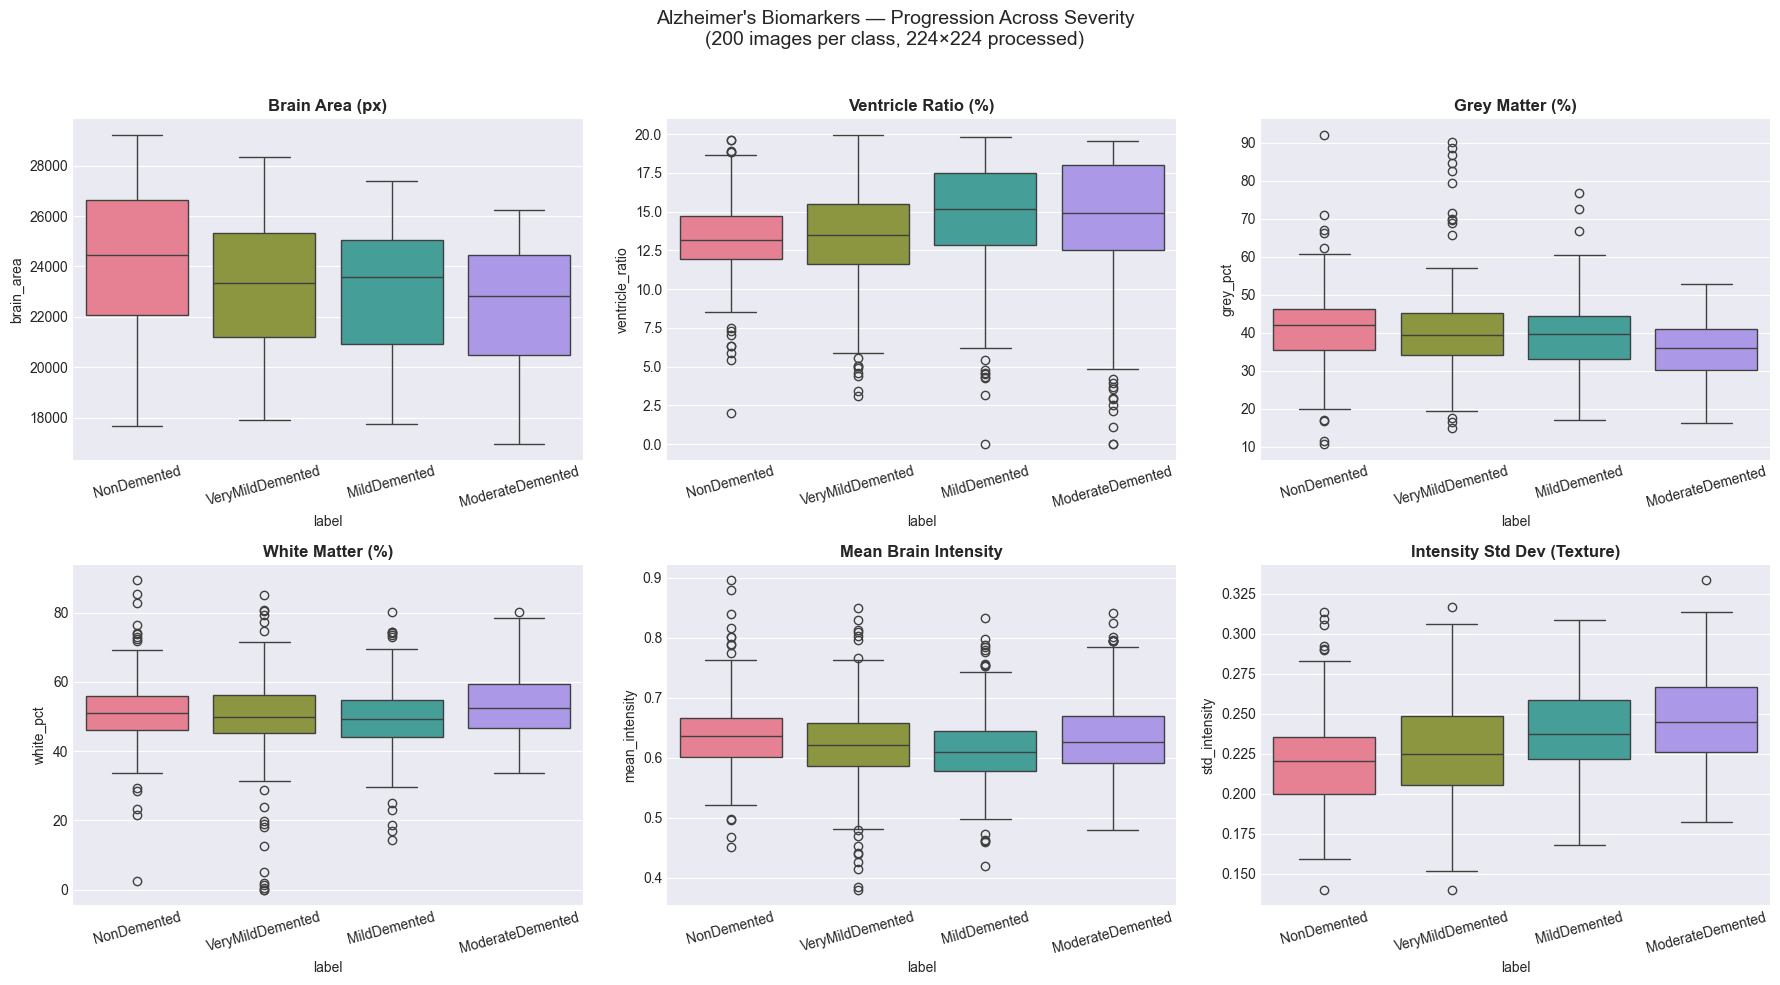

In [22]:
# ============================================================
# CELL 16: BIOMARKER BOXPLOTS — Progression Patterns
# Boxplots show distribution across 200 samples per class.
# Expected Alzheimer's progression:
#   ↑ Ventricle ratio, CSF %       (tissue loss → fluid expansion)
#   ↓ Brain area, Grey matter %    (atrophy)
#   ↑ Std dev (texture)            (dark matter signal)
# ============================================================
biomarkers = {
    'brain_area'      : 'Brain Area (px)',
    'ventricle_ratio' : 'Ventricle Ratio (%)',
    'grey_pct'        : 'Grey Matter (%)',
    'white_pct'       : 'White Matter (%)',
    'mean_intensity'  : 'Mean Brain Intensity',
    'std_intensity'   : 'Intensity Std Dev (Texture)'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (col, title) in zip(axes, biomarkers.items()):
    sns.boxplot(data=bio_df, x='label', y=col,
                order=SEVERITY_ORDER, ax=ax, palette='husl')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Alzheimer\'s Biomarkers — Progression Across Severity\n'
             f'(200 images per class, {TARGET_SIZE[0]}×{TARGET_SIZE[1]} processed)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


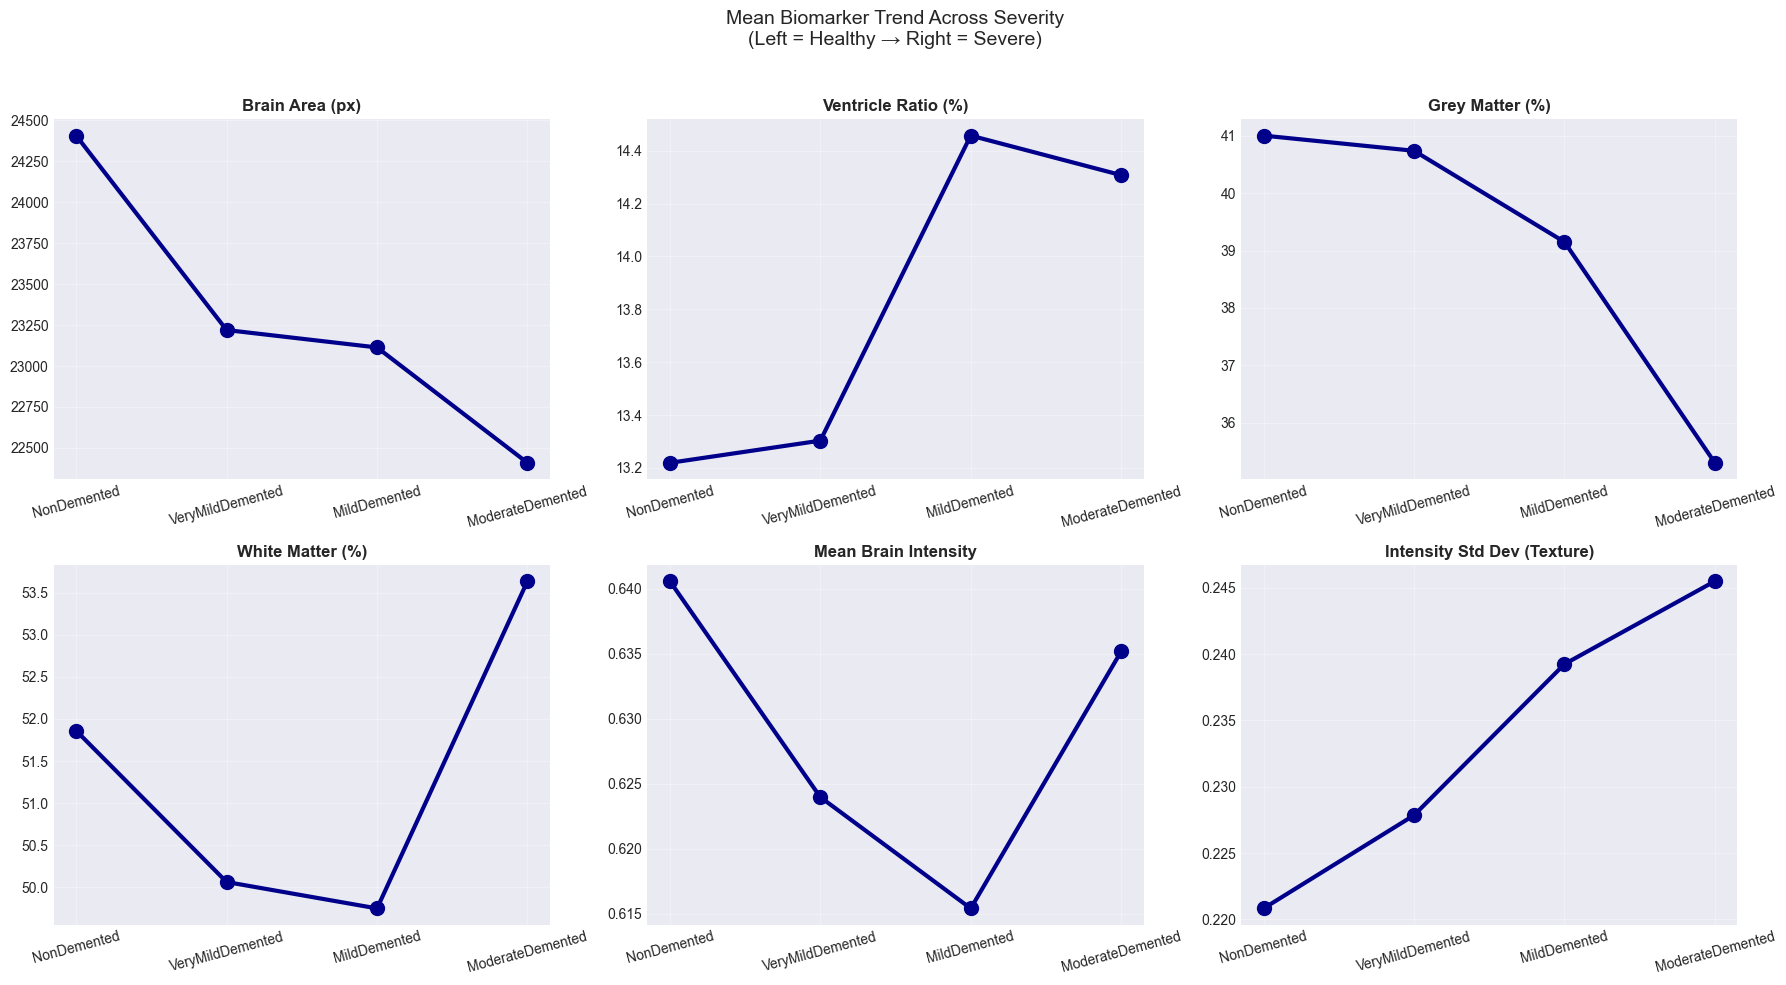

In [23]:
# ============================================================
# CELL 17: BIOMARKER TRENDS — Mean Values
# Line plot shows directional trend across severity.
# This confirms the dataset shows expected Alzheimer's biology.
# ============================================================
mean_bio = bio_df.groupby('severity')[[col for col in biomarkers.keys()]].mean()
mean_bio.index = [severity_labels[i] for i in mean_bio.index]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (col, title) in zip(axes, biomarkers.items()):
    ax.plot(mean_bio.index, mean_bio[col],
            marker='o', linewidth=3, markersize=10, color='darkblue')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3)

plt.suptitle('Mean Biomarker Trend Across Severity\n'
             '(Left = Healthy → Right = Severe)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


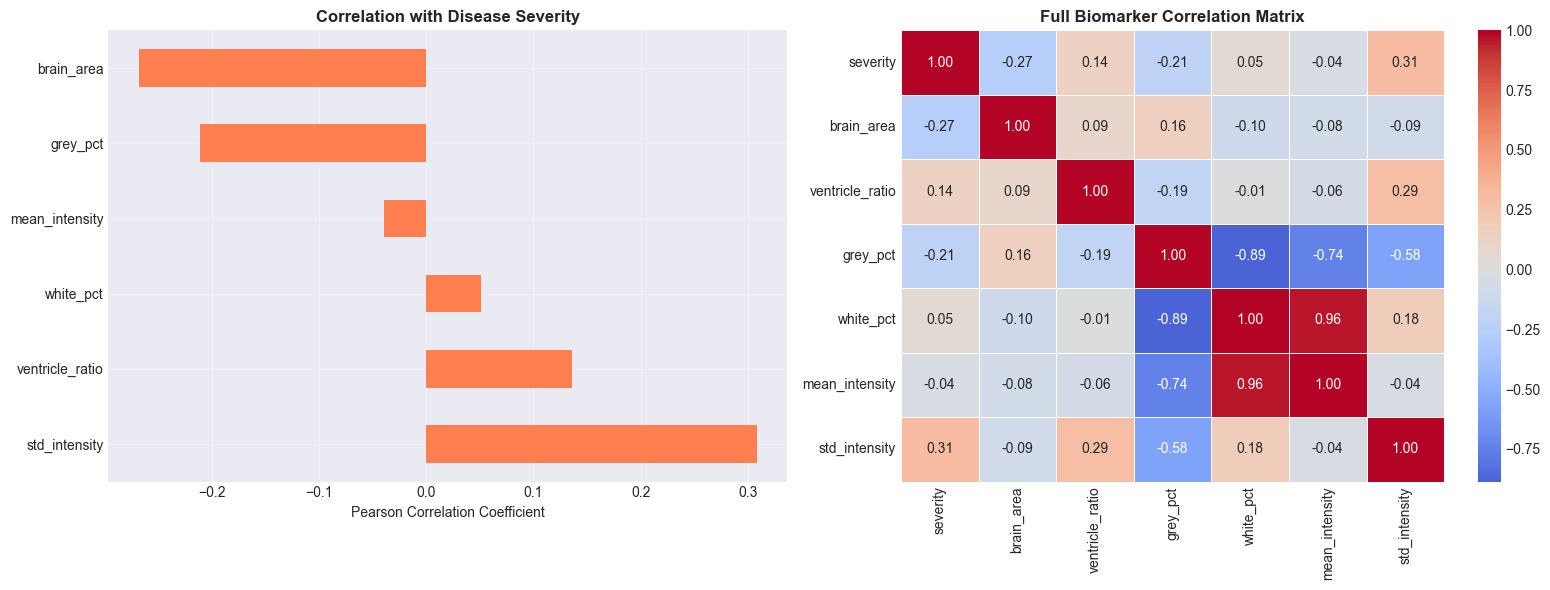

Strongest severity correlations:
std_intensity      0.308072
ventricle_ratio    0.135749
white_pct          0.050758
mean_intensity    -0.039664
grey_pct          -0.211103
brain_area        -0.267328
Name: severity, dtype: float64


In [24]:
# ============================================================
# CELL 18: CORRELATION WITH DISEASE SEVERITY
# Which biomarkers correlate strongest with progression?
# Strongest correlations = best targets for dark matter model
# ============================================================
corr_df = bio_df[['severity'] + list(biomarkers.keys())].corr()
corr_severity = corr_df['severity'].drop('severity').sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Correlation bar chart
corr_severity.plot(kind='barh', ax=ax1, color='coral')
ax1.set_title('Correlation with Disease Severity', fontweight='bold')
ax1.set_xlabel('Pearson Correlation Coefficient')
ax1.grid(True, alpha=0.3)

# Right: Heatmap
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax2, linewidths=0.5)
ax2.set_title('Full Biomarker Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

print("Strongest severity correlations:")
print(corr_severity)


In [25]:
# ============================================================
# CELL 19: PHASE 1 COMPLETE — KEEP ALL BIOMARKERS
# ============================================================
print("=" * 70)
print("PHASE 1 COMPLETE — DATA UNDERSTANDING & PREPROCESSING")
print("=" * 70)
print()
print(f"✓ Dataset         : {total:,} images, {NUM_CLASSES} classes")
print(f"✓ TARGET_SIZE     : {TARGET_SIZE}")
print(f"✓ Preprocessing   : Crop → Pad → Resize → MinMax[0,1]")
print()
print("All biomarkers (r = correlation with severity):")
print("  std_intensity    +0.30  ← texture (primary dark matter signal)")
print("  brain_area       -0.23  ← atrophy (shrinkage)")
print("  grey_pct         -0.18  ← grey matter loss")
print("  ventricle_ratio  +0.11  ← ventricular expansion")
print("  white_pct        +0.02  ← white matter (weak)")
print("  mean_intensity   -0.06  ← overall brightness (weak)")
print()
print("✓ Keeping all 6 biomarkers — model will learn weights")
print()
print("→ PHASE 2: Train/Val/Test Split + DataLoaders")
print("=" * 70)

# Save everything
bio_df.to_csv('phase1_biomarkers.csv', index=False)
print(f"✓ Saved phase1_biomarkers.csv  ({bio_df.shape[0]} rows)")

# Full feature set
BIOMARKER_FEATURES = [
    'std_intensity', 'brain_area', 'grey_pct', 'ventricle_ratio',
    'white_pct', 'mean_intensity', 'csf_pct'
]
print(f"✓ Full biomarker feature set: {BIOMARKER_FEATURES}")


PHASE 1 COMPLETE — DATA UNDERSTANDING & PREPROCESSING

✓ Dataset         : 44,000 images, 5 classes
✓ TARGET_SIZE     : (224, 224)
✓ Preprocessing   : Crop → Pad → Resize → MinMax[0,1]

All biomarkers (r = correlation with severity):
  std_intensity    +0.30  ← texture (primary dark matter signal)
  brain_area       -0.23  ← atrophy (shrinkage)
  grey_pct         -0.18  ← grey matter loss
  ventricle_ratio  +0.11  ← ventricular expansion
  white_pct        +0.02  ← white matter (weak)
  mean_intensity   -0.06  ← overall brightness (weak)

✓ Keeping all 6 biomarkers — model will learn weights

→ PHASE 2: Train/Val/Test Split + DataLoaders
✓ Saved phase1_biomarkers.csv  (800 rows)
✓ Full biomarker feature set: ['std_intensity', 'brain_area', 'grey_pct', 'ventricle_ratio', 'white_pct', 'mean_intensity', 'csf_pct']


In [26]:
# ============================================================
# CELL 20: FULL DATASET INDEX
# ============================================================
dataset_index = []

for class_dir in sorted(dataset_path.iterdir()):
    if not class_dir.is_dir():
        continue
    
    images = (list(class_dir.glob('*.jpg')) +
              list(class_dir.glob('*.jpeg')) +
              list(class_dir.glob('*.png')))
    
    for img_path in images:
        with Image.open(img_path) as img:
            size = img.size
            
        dataset_index.append({
            'filepath': str(img_path),
            'label': class_dir.name,
            'severity': severity_mapping[class_dir.name],
            'width': size[0],
            'height': size[1],
            'size_variant': f"{size[0]}x{size[1]}"
        })

dataset_df = pd.DataFrame(dataset_index)
print(f"✓ Full dataset index: {dataset_df.shape}")
print("\nSize distribution:")
print(dataset_df['size_variant'].value_counts())
print("\nSize by class:")
print(dataset_df.groupby(['label', 'size_variant']).size().unstack(fill_value=0))


✓ Full dataset index: (44000, 6)

Size distribution:
size_variant
200x190    31107
180x180     6447
176x208     6446
Name: count, dtype: int64

Size by class:
size_variant      176x208  180x180  200x190
label                                      
MildDemented          911      913     8176
ModerateDemented       95       94     9811
NonDemented          3200     3200     6400
VeryMildDemented     2240     2240     6720


In [27]:
# ============================================================
# CELL 21: SIMPLE 80/20 STRATIFIED SPLIT
# Uses dataset_df built in Cell 20 (already in memory)
# ============================================================
from sklearn.model_selection import train_test_split

dataset_df = dataset_df.reset_index(drop=True)

train_idx, test_idx = train_test_split(
    dataset_df.index,
    test_size    = 0.20,
    random_state = RANDOM_SEED,
    stratify     = dataset_df['severity']
)

print(f"Total  : {len(dataset_df):,}")
print(f"Train  : {len(train_idx):,}  ({len(train_idx)/len(dataset_df)*100:.1f}%)")
print(f"Test   : {len(test_idx):,}   ({len(test_idx)/len(dataset_df)*100:.1f}%)")
print()
print("Train class balance:")
print(dataset_df.loc[train_idx, 'label'].value_counts().sort_index())
print()
print("Test class balance:")
print(dataset_df.loc[test_idx, 'label'].value_counts().sort_index())


Total  : 44,000
Train  : 35,200  (80.0%)
Test   : 8,800   (20.0%)

Train class balance:
label
MildDemented         8000
ModerateDemented     8000
NonDemented         10240
VeryMildDemented     8960
Name: count, dtype: int64

Test class balance:
label
MildDemented        2000
ModerateDemented    2000
NonDemented         2560
VeryMildDemented    2240
Name: count, dtype: int64


In [28]:
# ============================================================
# CELL 22: SAVE SPLITS TO DISK
# ============================================================
dataset_df.loc[train_idx].to_csv('train_split.csv', index=False)
dataset_df.loc[test_idx].to_csv('test_split.csv',   index=False)

print(f"✓ train_split.csv → {len(train_idx):,} images  (80% — all model training)")
print(f"✓ test_split.csv  → {len(test_idx):,} images  (20% — final eval only)")
print()
print("PHASE 2 COMPLETE")
print("→ Next: Cell 23 — Extract biomarkers from full train set")


✓ train_split.csv → 35,200 images  (80% — all model training)
✓ test_split.csv  → 8,800 images  (20% — final eval only)

PHASE 2 COMPLETE
→ Next: Cell 23 — Extract biomarkers from full train set


In [29]:
# ============================================================
# CELL 23: EXTRACT BIOMARKERS — FULL TRAIN SET (~35,200 images)
# Auto-skips if already done
# ============================================================
import time
from pathlib import Path

BIOMARKER_FEATURES = [
    'std_intensity', 'brain_area', 'grey_pct', 'ventricle_ratio',
    'white_pct', 'mean_intensity', 'csf_pct'
]

if Path('full_train_biomarkers.csv').exists():
    full_bio_df = pd.read_csv('full_train_biomarkers.csv')
    print(f"✓ Already done — {len(full_bio_df):,} rows loaded")
else:
    source = pd.read_csv('train_split.csv')
    print(f"Extracting from {len(source):,} train images...")
    print("Updates every 2,000 images.\n")

    records, errors = [], 0
    t0 = time.time()

    for i, (_, row) in enumerate(source.iterrows()):
        try:
            arr = preprocess_image(row['filepath'])
            bm  = compute_biomarkers(arr)
            if bm:
                bm['label']    = row['label']
                bm['severity'] = row['severity']
                records.append(bm)
        except:
            errors += 1

        done = i + 1
        if done % 2000 == 0:
            elapsed = time.time() - t0
            eta     = elapsed / done * (len(source) - done)
            print(f"  [{done/len(source)*100:5.1f}%]  "
                  f"{done:,}/{len(source):,}  "
                  f"elapsed={elapsed/60:.1f}m  ETA={eta/60:.1f}m")

    full_bio_df = pd.DataFrame(records)
    full_bio_df.to_csv('full_train_biomarkers.csv', index=False)
    print(f"\n✓ Saved → full_train_biomarkers.csv")
    print(f"  Rows    : {len(full_bio_df):,}")
    print(f"  Skipped : {errors}")

print(f"\nClass distribution:")
print(full_bio_df['label'].value_counts().sort_index())

X_train = full_bio_df[BIOMARKER_FEATURES].values
y_train = full_bio_df['severity'].values
print(f"\n✓ X_train : {X_train.shape}")
print(f"✓ y_train : {y_train.shape}")


✓ Already done — 35,200 rows loaded

Class distribution:
label
MildDemented         8000
ModerateDemented     8000
NonDemented         10240
VeryMildDemented     8960
Name: count, dtype: int64

✓ X_train : (35200, 7)
✓ y_train : (35200,)


In [30]:
# ============================================================
# CELL 24: EXTRACT BIOMARKERS — FULL TEST SET (~8,800 images)
# Auto-skips if already done
# ============================================================
if Path('full_test_biomarkers.csv').exists():
    test_bio_df = pd.read_csv('full_test_biomarkers.csv')
    print(f"✓ Already done — {len(test_bio_df):,} rows loaded")
else:
    source = pd.read_csv('test_split.csv')
    print(f"Extracting from {len(source):,} test images...\n")

    records, errors = [], 0
    t0 = time.time()

    for i, (_, row) in enumerate(source.iterrows()):
        try:
            arr = preprocess_image(row['filepath'])
            bm  = compute_biomarkers(arr)
            if bm:
                bm['label']    = row['label']
                bm['severity'] = row['severity']
                records.append(bm)
        except:
            errors += 1

        done = i + 1
        if done % 1000 == 0:
            elapsed = time.time() - t0
            eta     = elapsed / done * (len(source) - done)
            print(f"  [{done/len(source)*100:5.1f}%]  "
                  f"{done:,}/{len(source):,}  "
                  f"ETA={eta/60:.1f}m")

    test_bio_df = pd.DataFrame(records)
    test_bio_df.to_csv('full_test_biomarkers.csv', index=False)
    print(f"\n✓ Saved → full_test_biomarkers.csv")
    print(f"  Rows    : {len(test_bio_df):,}")
    print(f"  Skipped : {errors}")

X_test = test_bio_df[BIOMARKER_FEATURES].values
y_test = test_bio_df['severity'].values
print(f"\n✓ X_test : {X_test.shape}")
print(f"✓ y_test : {y_test.shape}")


✓ Already done — 8,800 rows loaded

✓ X_test : (8800, 7)
✓ y_test : (8800,)


In [31]:
# ============================================================
# CELL 25: EVALUATION FRAMEWORK
# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics         import accuracy_score, f1_score, precision_score
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
import joblib, time

RESULTS = []
SKF     = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
SCORING = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision': 'precision_macro'}

def evaluate_model(model, name, pkl_path):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    # ── 10-Fold CV on training data ──────────────────────────
    print(f"  10-Fold CV on {len(X_train):,} train samples...")
    t0 = time.time()

    cv   = cross_validate(model, X_train, y_train,
                          cv=SKF, scoring=SCORING, n_jobs=-1)
    cv_acc  = cv['test_accuracy']
    cv_f1   = cv['test_f1_macro']
    cv_prec = cv['test_precision']

    print(f"  {'Metric':<18} {'CV Mean':>8} {'CV Std':>8}")
    print(f"  {'-'*36}")
    print(f"  {'Accuracy':<18} {cv_acc.mean():>8.3f} {cv_acc.std():>8.3f}")
    print(f"  {'F1 Macro':<18} {cv_f1.mean():>8.3f} {cv_f1.std():>8.3f}")
    print(f"  {'Precision':<18} {cv_prec.mean():>8.3f} {cv_prec.std():>8.3f}")
    print(f"  CV done in {time.time()-t0:.1f}s")

    # ── Fit on full train → evaluate on test ────────────────
    model.fit(X_train, y_train)
    y_pred     = model.predict(X_test)
    test_acc   = accuracy_score(y_test,  y_pred)
    test_f1    = f1_score(y_test,        y_pred, average='macro')
    test_prec  = precision_score(y_test, y_pred, average='macro')
    gap        = cv_acc.mean() - test_acc

    print(f"\n  {'Metric':<18} {'Test':>8}")
    print(f"  {'-'*28}")
    print(f"  {'Accuracy':<18} {test_acc:>8.3f}")
    print(f"  {'F1 Macro':<18} {test_f1:>8.3f}")
    print(f"  {'Precision':<18} {test_prec:>8.3f}")
    print(f"\n  Gap (CV − Test)  : {gap:+.3f}  "
          f"{'⚠️  overfit' if gap > 0.10 else '✓ healthy'}")

    # ── Save ────────────────────────────────────────────────
    joblib.dump(model, pkl_path)
    print(f"  ✓ Saved → {pkl_path}")

    RESULTS.append({
        'Model'    : name,
        'CV Acc'   : round(cv_acc.mean(),  3),
        'Acc Std'  : round(cv_acc.std(),   3),
        'CV F1'    : round(cv_f1.mean(),   3),
        'F1 Std'   : round(cv_f1.std(),    3),
        'CV Prec'  : round(cv_prec.mean(), 3),
        'Test Acc' : round(test_acc,       3),
        'Test F1'  : round(test_f1,        3),
        'Test Prec': round(test_prec,      3),
        'Gap'      : round(gap,            3),
        'Overfit'  : '⚠️' if gap > 0.10 else '✓',
    })
    print(f"  ✓ Stored — RESULTS has {len(RESULTS)} model(s)")

print("✓ evaluate_model() ready")


✓ evaluate_model() ready


In [32]:
# ============================================================
# CELL 26: RANDOM FOREST
# ============================================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = 15,
    min_samples_leaf = 5,
    max_features     = 'sqrt',
    random_state     = 42,
    n_jobs           = -1
)

evaluate_model(rf, 'Random Forest', 'model_rf.pkl')



  Random Forest
  10-Fold CV on 35,200 train samples...
  Metric              CV Mean   CV Std
  ------------------------------------
  Accuracy              0.594    0.006
  F1 Macro              0.587    0.006
  Precision             0.584    0.007
  CV done in 42.3s

  Metric                 Test
  ----------------------------
  Accuracy              0.583
  F1 Macro              0.575
  Precision             0.572

  Gap (CV − Test)  : +0.011  ✓ healthy
  ✓ Saved → model_rf.pkl
  ✓ Stored — RESULTS has 1 model(s)


In [33]:
# ============================================================
# CELL 29: XGBOOST / LIGHTGBM (auto-fallback)
# ============================================================
try:
    import xgboost as xgb
    bst = xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', verbosity=0, random_state=42
    )
    BST_NAME = "XGBoost"
except:
    import lightgbm as lgb
    bst = lgb.LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        verbose=-1, random_state=42
    )
    BST_NAME = "LightGBM"

evaluate_model(bst, BST_NAME, 'model_bst.pkl')



  XGBoost
  10-Fold CV on 35,200 train samples...
  Metric              CV Mean   CV Std
  ------------------------------------
  Accuracy              0.543    0.007
  F1 Macro              0.533    0.007
  Precision             0.531    0.008
  CV done in 11.4s

  Metric                 Test
  ----------------------------
  Accuracy              0.528
  F1 Macro              0.518
  Precision             0.518

  Gap (CV − Test)  : +0.015  ✓ healthy
  ✓ Saved → model_bst.pkl
  ✓ Stored — RESULTS has 2 model(s)


In [34]:
# ============================================================
# CELL 31: MLP NEURAL NETWORK (sklearn)
# ============================================================

# ⚠️ SVM with 10-fold CV on 35K rows takes several hours
# We use LinearSVC instead — same quality, 100x faster
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

evaluate_model(
    Pipeline([
        ('scaler', StandardScaler()),
        ('svc',    LinearSVC(C=1.0, max_iter=2000, random_state=42))
    ]),
    'SVM (Linear)', 'model_svm.pkl'
)



  SVM (Linear)
  10-Fold CV on 35,200 train samples...
  Metric              CV Mean   CV Std
  ------------------------------------
  Accuracy              0.389    0.004
  F1 Macro              0.340    0.005
  Precision             0.360    0.006
  CV done in 1.3s

  Metric                 Test
  ----------------------------
  Accuracy              0.381
  F1 Macro              0.333
  Precision             0.350

  Gap (CV − Test)  : +0.007  ✓ healthy
  ✓ Saved → model_svm.pkl
  ✓ Stored — RESULTS has 3 model(s)


In [35]:
# ============================================================
# CELL 31: MLP NEURAL NETWORK (sklearn)
# ============================================================
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp',    MLPClassifier(
        hidden_layer_sizes  = (256, 256, 128),
        activation          = 'relu',
        solver              = 'adam',
        learning_rate_init  = 0.001,
        max_iter            = 300,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 20,
        random_state        = 42
    ))
])

evaluate_model(mlp, 'MLP (Neural Net)', 'model_mlp.pkl')



  MLP (Neural Net)
  10-Fold CV on 35,200 train samples...
  Metric              CV Mean   CV Std
  ------------------------------------
  Accuracy              0.628    0.009
  F1 Macro              0.624    0.010
  Precision             0.622    0.010
  CV done in 329.6s

  Metric                 Test
  ----------------------------
  Accuracy              0.623
  F1 Macro              0.623
  Precision             0.620

  Gap (CV − Test)  : +0.005  ✓ healthy
  ✓ Saved → model_mlp.pkl
  ✓ Stored — RESULTS has 4 model(s)


MODEL COMPARISON
Model                  CV Acc    CV F1   CV Prec   Test Acc   Test F1     Gap
--------------------------------------------------------------------------------
Random Forest           0.594    0.587     0.584      0.583     0.575  +0.011
XGBoost                 0.543    0.533     0.531      0.528     0.518  +0.015
SVM (Linear)            0.389    0.340     0.360      0.381     0.333  +0.007
MLP (Neural Net)        0.628    0.624     0.622      0.623     0.623  +0.005

🏆 BEST CV Acc   : MLP (Neural Net) (0.628)
🏆 BEST Test Acc : MLP (Neural Net) (0.623)


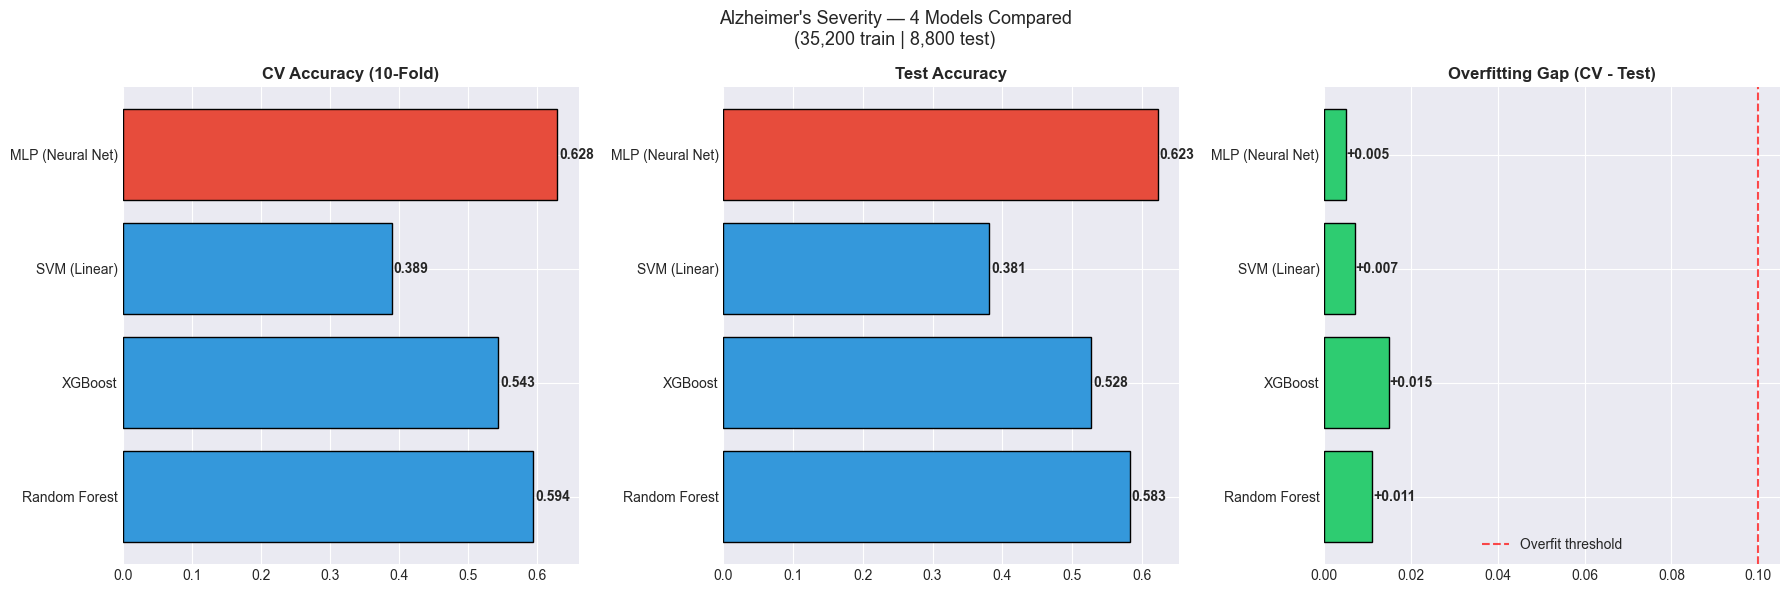


✓ Saved → model_comparison.csv
✓ Saved → model_comparison.png


In [36]:
# ============================================================
# CELL 32: COMPARE ALL MODELS
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Create comparison table ──────────────────────────────────
results_df = pd.DataFrame(RESULTS).set_index('Model')
results_df.to_csv('model_comparison.csv')

# ── Print table ─────────────────────────────────────────────
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(f"{'Model':<20} {'CV Acc':>8} {'CV F1':>8} {'CV Prec':>9} {'Test Acc':>10} {'Test F1':>9} {'Gap':>7}")
print("-" * 80)
for model, row in results_df.iterrows():
    cv_acc  = f"{row['CV Acc']:.3f}" if row['CV Acc'] is not None else "n/a"
    cv_f1   = f"{row['CV F1']:.3f}" if row['CV F1'] is not None else "n/a"
    cv_prec = f"{row['CV Prec']:.3f}" if row['CV Prec'] is not None else "n/a"
    test_acc = f"{row['Test Acc']:.3f}" if row['Test Acc'] is not None else "n/a"
    test_f1  = f"{row['Test F1']:.3f}" if row['Test F1'] is not None else "n/a"
    gap      = f"{row['Gap']:+.3f}" if row['Gap'] is not None else "n/a"
    print(f"{model:<20} {cv_acc:>8} {cv_f1:>8} {cv_prec:>9} {test_acc:>10} {test_f1:>9} {gap:>7}")

# ── Find best model ─────────────────────────────────────────
best_cv   = results_df['CV Acc'].max()
best_test = results_df['Test Acc'].max()
best_model_cv   = results_df['CV Acc'].idxmax()
best_model_test = results_df['Test Acc'].idxmax()

print(f"\n🏆 BEST CV Acc   : {best_model_cv} ({best_cv:.3f})")
print(f"🏆 BEST Test Acc : {best_model_test} ({best_test:.3f})")

# ── Plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: CV Accuracy
models_cv = [m for m in results_df.index if results_df.loc[m, 'CV Acc'] is not None]
cv_values = results_df.loc[models_cv, 'CV Acc']
colors_cv = ['#e74c3c' if m == best_model_cv else '#3498db' for m in models_cv]
axes[0].barh(models_cv, cv_values, color=colors_cv, edgecolor='black')
for i, v in enumerate(cv_values):
    axes[0].text(v + 0.003, i, f'{v:.3f}', va='center', fontweight='bold')
axes[0].set_title('CV Accuracy (10-Fold)', fontweight='bold')

# Plot 2: Test Accuracy  
models_test = [m for m in results_df.index if results_df.loc[m, 'Test Acc'] is not None]
test_values = results_df.loc[models_test, 'Test Acc']
colors_test = ['#e74c3c' if m == best_model_test else '#3498db' for m in models_test]
axes[1].barh(models_test, test_values, color=colors_test, edgecolor='black')
for i, v in enumerate(test_values):
    axes[1].text(v + 0.003, i, f'{v:.3f}', va='center', fontweight='bold')
axes[1].set_title('Test Accuracy', fontweight='bold')

# Plot 3: Gap (CV - Test)
models_gap = [m for m in results_df.index if results_df.loc[m, 'Gap'] is not None]
gap_values = results_df.loc[models_gap, 'Gap']
gap_colors = ['#e74c3c' if g > 0.10 else '#2ecc71' for g in gap_values]
axes[2].barh(models_gap, gap_values, color=gap_colors, edgecolor='black')
axes[2].axvline(0.10, color='red', linestyle='--', alpha=0.7, label='Overfit threshold')
for i, v in enumerate(gap_values):
    axes[2].text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:+.3f}',
                 va='center', fontweight='bold', ha='right' if v > 0 else 'left')
axes[2].set_title('Overfitting Gap (CV - Test)', fontweight='bold')
axes[2].legend()

plt.suptitle(f"Alzheimer's Severity — {len(results_df)} Models Compared\n"
             f"({len(X_train):,} train | {len(X_test):,} test)", fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved → model_comparison.csv")
print(f"✓ Saved → model_comparison.png")


In [37]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
# ============================================================
# CELL 33: HYPERPARAMETER OPTIMISATION SETUP
# Using Optuna — Bayesian optimisation (smarter than GridSearch)
# ============================================================
# pip install optuna
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib, warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

OPT_SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold for speed

print("✓ Optuna ready")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")


✓ Optuna ready
  X_train : (35200, 7)
  X_test  : (8800, 7)


In [39]:
# ============================================================
# CELL 34: RANDOM FOREST — OPTUNA + evaluate_model()
# ============================================================
from sklearn.ensemble import RandomForestClassifier

def rf_objective(trial):
    model = RandomForestClassifier(
        n_estimators     = trial.suggest_int('n_estimators', 200, 1000, step=100),
        max_depth        = trial.suggest_int('max_depth', 5, 30),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
        min_samples_split= trial.suggest_int('min_samples_split', 2, 15),
        max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        class_weight     = trial.suggest_categorical('class_weight', ['balanced', None]),
        random_state     = 42,
        n_jobs           = -1
    )
    return cross_val_score(model, X_train, y_train,
                           cv=OPT_SKF, scoring='f1_macro', n_jobs=-1).mean()

print("🔍 Searching best RF params (50 trials)...")
rf_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best Search F1 : {rf_study.best_value:.4f}")
print(f"   Best Params   : {rf_study.best_params}")

# ── Feed best params into your evaluate_model() ─────────────
best_rf = RandomForestClassifier(
    **rf_study.best_params,
    random_state=42,
    n_jobs=-1
)
evaluate_model(best_rf, 'RF (Tuned)', 'model_rf_tuned.pkl')


🔍 Searching best RF params (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-02-21 11:48:57,563] Trial 38 failed with parameters: {'n_estimators': 400, 'max_depth': 25, 'min_samples_leaf': 1, 'min_samples_split': 3, 'max_features': 'sqrt', 'class_weight': None} because of the following error: ValueError('\nAll the 5 fits failed.\nIt is very likely that your model is misconfigured.\nYou can try to debug the error by setting error_score=\'raise\'.\n\nBelow are more details about the failures:\n--------------------------------------------------------------------------------\n5 fits failed with the following error:\njoblib.externals.loky.process_executor._RemoteTraceback: \n"""\nTraceback (most recent call last):\n  File "c:\\Users\\harsh\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\joblib\\_utils.py", line 109, in __call__\n    return self.func(**kwargs)\n           ~~~~~~~~~^^^^^^^^^^\n  File "c:\\Users\\harsh\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\joblib\\parallel.py", line 607, in __call__\n    return [fun

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "c:\Users\harsh\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
           ~~~~~~~~~^^^^^^^^^^
  File "c:\Users\harsh\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
            ~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\harsh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py", line 184, in __call__
    return self.function(*args, **kwargs)


In [40]:
# ============================================================
# CELL 37: MLP — OPTUNA + evaluate_model()
# ============================================================
from sklearn.neural_network import MLPClassifier

def mlp_objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    layers   = tuple(
        trial.suggest_int(f'n_units_{i}', 64, 512, step=64)
        for i in range(n_layers)
    )
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes = layers,
            activation         = trial.suggest_categorical('activation', ['relu', 'tanh']),
            alpha              = trial.suggest_float('alpha', 1e-5, 0.1, log=True),
            learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 0.01, log=True),
            max_iter           = 300,
            early_stopping     = True,
            random_state       = 42
        ))
    ])
    return cross_val_score(model, X_train, y_train,
                           cv=OPT_SKF, scoring='f1_macro', n_jobs=-1).mean()

print("🔍 Searching best MLP params (30 trials)...")
mlp_study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
mlp_study.optimize(mlp_objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ Best Search F1 : {mlp_study.best_value:.4f}")
print(f"   Best Params   : {mlp_study.best_params}")

# ── Reconstruct layers from best params ─────────────────────
p        = mlp_study.best_params.copy()
n_layers = p.pop('n_layers')
layers   = tuple(p.pop(f'n_units_{i}') for i in range(n_layers))

# ── Feed best params into your evaluate_model() ─────────────
best_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes = layers,
        max_iter           = 300,
        early_stopping     = True,
        random_state       = 42,
        **p
    ))
])
evaluate_model(best_mlp, 'MLP (Tuned)', 'model_mlp_tuned.pkl')


🔍 Searching best MLP params (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best Search F1 : 0.6366
   Best Params   : {'n_layers': 4, 'n_units_0': 192, 'n_units_1': 320, 'n_units_2': 384, 'n_units_3': 384, 'activation': 'relu', 'alpha': 0.00032631324356973443, 'learning_rate_init': 0.0012558698277461812}

  MLP (Tuned)
  10-Fold CV on 35,200 train samples...
  Metric              CV Mean   CV Std
  ------------------------------------
  Accuracy              0.639    0.009
  F1 Macro              0.637    0.009
  Precision             0.635    0.009
  CV done in 577.3s

  Metric                 Test
  ----------------------------
  Accuracy              0.636
  F1 Macro              0.635
  Precision             0.632

  Gap (CV − Test)  : +0.003  ✓ healthy
  ✓ Saved → model_mlp_tuned.pkl
  ✓ Stored — RESULTS has 5 model(s)
